In [21]:
from langchain_core.messages import AIMessage, HumanMessage
from pprint import pprint

messages = [AIMessage(content="Please tell me how can i Help", name="LLMModel")]
messages.append(HumanMessage(content="I want to learn coding", name = "Kishore"))
messages.append(AIMessage(content="Which programming language you would like to learn", name="LLMModel"))
messages.append(HumanMessage(content="I would like to learn python programming language", name="Kishore"))

for message in messages:
    message.pretty_print()

================================== Ai Message ==================================
Name: LLMModel

Please tell me how can i Help
================================ Human Message =================================
Name: Kishore

I want to learn coding
================================== Ai Message ==================================
Name: LLMModel

Which programming language you would like to learn
================================ Human Message =================================
Name: Kishore

I would like to learn python programming language


We can use the above constructed messages and pass all the AI, Human messages into any LLM's chat model

In [22]:
import os
from dotenv import load_dotenv
load_dotenv()
os.environ["GROQ_API_KEY"]= os.getenv("GROQ_API_KEY")

In [23]:
from langchain_groq import ChatGroq

llm = ChatGroq(model="qwen/qwen3-32b")
result = llm.invoke(messages)


### OTher options to print result -> response_metadata, content, content_blocks

In [24]:
print(str(result.content))

<think>
Okay, the user wants to learn Python. Let me start by breaking down how to approach this. First, I need to consider their current level. Since they mentioned wanting to learn, they might be a beginner, so the resources should be suitable for that.

I should outline the steps they can take. Starting with the basics is essential. Maybe suggest an interactive platform like Codecademy or freeCodeCamp. Those are great for beginners because they offer hands-on practice. Also, recommending a textbook like "Python Crash Course" or "Automate the Boring Stuff" could help them understand the fundamentals better.

Next, practice is key. They need to write code regularly. Maybe recommend solving problems on platforms like LeetCode or HackerRank. These sites have a variety of problems that can help reinforce what they've learned. 

Projects are important to apply knowledge. Suggesting small projects like a calculator or a to-do list app can help them see real-world applications. As they prog

### Tools - can be api's, third party tools

LLM models can understand what tool to be called when a user prompt (in natural language) is given based  ON THE DOCSTRING of the tool function/method()

In [25]:
# Define a add function with docstring

def add(a:int,b:int) -> int:
    """
    Adds a and b

    Args :
        a(int) : first int
        b(int) : second int

    returns:
        int

    """

    return a+b

In [26]:
llm

ChatGroq(profile={'max_input_tokens': 131072, 'max_output_tokens': 16384, 'image_inputs': False, 'audio_inputs': False, 'video_inputs': False, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': True, 'tool_calling': True}, client=<groq.resources.chat.completions.Completions object at 0x112861f10>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x112857e50>, model_name='qwen/qwen3-32b', model_kwargs={}, groq_api_key=SecretStr('**********'))

In [27]:
llm_with_tools = llm.bind_tools([add]) # Bind the add tool and invoke it by giving user input
llm_with_tools.invoke([HumanMessage(content = f"what is 2 plus 2", name = "Kishore")])

AIMessage(content='', additional_kwargs={'reasoning_content': 'Okay, the user is asking "what is 2 plus 2". Let me see. I need to figure out which function to use here. The available tool is the add function, which takes two integers and returns their sum. The parameters required are a and b, both integers. The user\'s question is straightforward: adding 2 and 2. So I should call the add function with a=2 and b=2. There\'s no ambiguity here. I just need to make sure the arguments are correctly formatted as integers in the JSON object. Let me double-check the function\'s parameters. Yep, they\'re required and should be integers. Alright, the tool call should be correct.\n', 'tool_calls': [{'id': '80gpsq1kf', 'function': {'arguments': '{"a":2,"b":2}', 'name': 'add'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 169, 'prompt_tokens': 185, 'total_tokens': 354, 'completion_time': 0.297012194, 'completion_tokens_details': {'reasoning_tokens': 140}, 'prompt_t

### Using messages as state

In [28]:
from typing_extensions import TypedDict
from langchain_core.messages import AnyMessage
from langgraph.graph.message import add_messages
from typing import Annotated

class State(TypedDict):
    messages:Annotated[list[AnyMessage], add_messages]

We need to use Reducer functions like add_messages so that the node updates doesn't replace the exising state value but append it to the variable
For example - messages:Annotated[list[AnyMessage], add_messages]

## Reducers with add_messages

In [29]:
initial_messages = [AIMessage(content=f"Please tell me how can i help", name = "LLMModel")]
initial_messages.append(HumanMessage(content= f"I want to learn coding", name = "Kishore"))
initial_messages

[AIMessage(content='Please tell me how can i help', additional_kwargs={}, response_metadata={}, name='LLMModel', tool_calls=[], invalid_tool_calls=[]),
 HumanMessage(content='I want to learn coding', additional_kwargs={}, response_metadata={}, name='Kishore')]

In [30]:
ai_message = AIMessage(content=f"Which programming language do you want to learn?", name = "LLMModel")
ai_message

AIMessage(content='Which programming language do you want to learn?', additional_kwargs={}, response_metadata={}, name='LLMModel', tool_calls=[], invalid_tool_calls=[])

Below is the reducer add_messages that is used to append the state value messages instead of overriding

In [31]:
add_messages(initial_messages, ai_message)

[AIMessage(content='Please tell me how can i help', additional_kwargs={}, response_metadata={}, name='LLMModel', id='de55639d-8e70-4147-8d17-11b1657a9e1c', tool_calls=[], invalid_tool_calls=[]),
 HumanMessage(content='I want to learn coding', additional_kwargs={}, response_metadata={}, name='Kishore', id='21aad03f-73f9-444b-9fc7-6962b4012b4f'),
 AIMessage(content='Which programming language do you want to learn?', additional_kwargs={}, response_metadata={}, name='LLMModel', id='32ec4fbc-4c57-4b96-9c7d-e68a70623303', tool_calls=[], invalid_tool_calls=[])]

In [32]:
## chatbot node functionality
def llm_tool(state:State):
    return {"messages":[llm_with_tools.invoke(state["messages"])]}

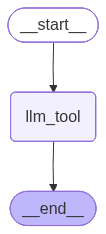

In [33]:
from IPython.display import Image, display
from langgraph.graph import START, END, StateGraph

builder = StateGraph(State)
builder.add_node("llm_tool", llm_tool)
builder.add_edge(START, "llm_tool")
builder.add_edge("llm_tool", END)

graph = builder.compile()

display(Image(graph.get_graph().draw_mermaid_png()))

In [34]:
## invocation

messages = graph.invoke({"messages": "What is 2 plus 2"})

In [35]:
for message in messages["messages"]:
    message.pretty_print()

================================ Human Message =================================

What is 2 plus 2
================================== Ai Message ==================================
Tool Calls:
  add (kesrsr1x1)
 Call ID: kesrsr1x1
  Args:
    a: 2
    b: 2


In [37]:
tools = [add]

In [39]:
from langgraph.prebuilt import ToolNode, tools_condition

builder = StateGraph(State)
# add node
builder.add_node("llm_tool", llm_tool)
builder.add_node("tools", ToolNode(tools))
# add edge
builder.add_edge(START, "llm_tool")
builder.add_conditional_edges("llm_tool",
                              #If the result is a tool call, tools_condition will route to tools
                              # if the result is NOT a tool call, tools_condition routes to END
                               tools_condition)
builder.add_edge("tools", END)

graph_builder = builder.compile()

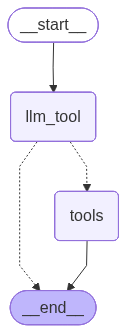

In [40]:
display(Image(graph_builder.get_graph().draw_mermaid_png()))

In [41]:
# invocation

messages = graph_builder.invoke({"messages":"What is 2 plus 2"})

for message in messages["messages"]:
    message.pretty_print()

================================ Human Message =================================

What is 2 plus 2
================================== Ai Message ==================================
Tool Calls:
  add (rf3xntw38)
 Call ID: rf3xntw38
  Args:
    a: 2
    b: 2
================================= Tool Message =================================
Name: add

4


Since it's a user question is math based and the appropriate add function is available, it took a tool call route and gave us answer 4.

Let's now try a non math based question and see a path taken

In [42]:
messages = graph_builder.invoke({"messages":"What is machine learning"})

for message in messages["messages"]:
    message.pretty_print()

================================ Human Message =================================

What is machine learning
================================== Ai Message ==================================

Machine learning is a subset of artificial intelligence (AI) that focuses on developing algorithms and models that enable computers to learn patterns and make decisions from data without being explicitly programmed for specific tasks. Instead of relying on rigid instructions, machine learning systems improve their performance over time by identifying patterns in data.

**Key concepts**:
- **Learning from data**: Systems use training data to detect patterns (e.g., recognizing spam emails by analyzing thousands of examples).
- **Adaptability**: Models adjust their behavior as they process more data (e.g., improving voice recognition accuracy with usage).
- **Types of learning**:
  - *Supervised learning*: Uses labeled data (e.g., predicting house prices based on historical sales).
  - *Unsupervised lea

Since the question was about a general topic - machine learning, the llm decided not to use a tool as it's inappropriate and the route it took is without calling the tool node

**Key concepts**:
- **Learning from data**: Systems use training data to detect patterns (e.g., recognizing spam emails by analyzing thousands of examples).
- **Adaptability**: Models adjust their behavior as they process more data (e.g., improving voice recognition accuracy with usage).
- **Types of learning**:
  - *Supervised learning*: Uses labeled data (e.g., predicting house prices based on historical sales).
  - *Unsupervised learning*: Finds hidden patterns in unlabeled data (e.g., grouping customers by purchasing behavior).
  - *Reinforcement learning*: Learns by trial-and-error with rewards/penalties (e.g., training a robot to walk).
